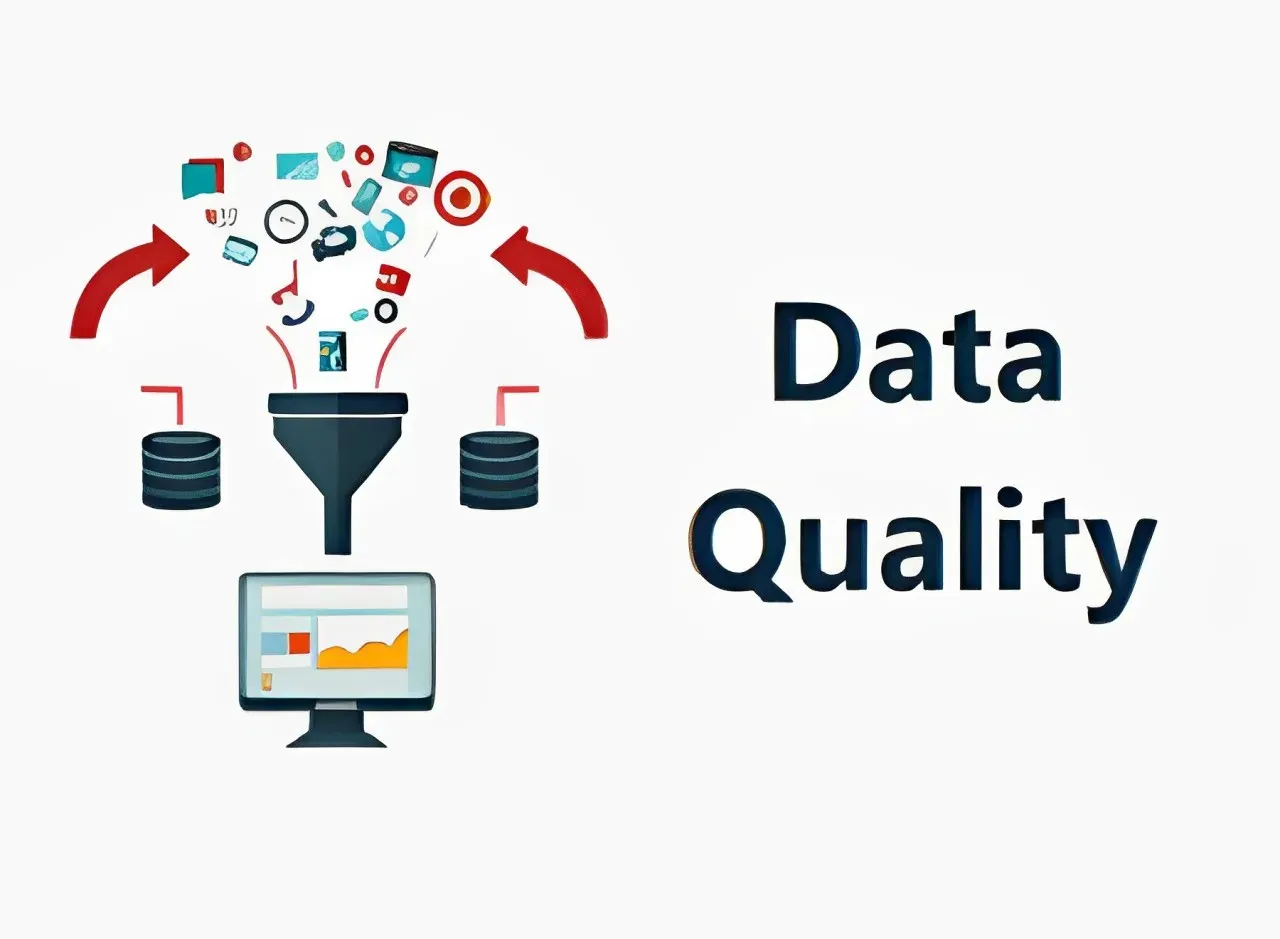

# 01. Data Quality Assessment Report

## Problem Statement

Restaurant business decisions rely heavily on accurate and reliable data. However, operational datasets often contain missing values, duplicate records, invalid entries, and data quality issues that can impact business analysis and machine learning performance.

Before performing any cleaning, analysis, or modeling, it is important to assess the current quality of the dataset and identify potential problems.

---

## Business Objective

The objective of this notebook is to evaluate the quality of the Meghana Foods Branch Performance Dataset and identify issues that may affect downstream analytics.

This assessment helps:

• Detect missing values

• Identify duplicate records

• Validate business metrics

• Detect invalid ratings

• Detect invalid delivery times

• Identify unusual values and outliers

---

## Project Lifecycle Position

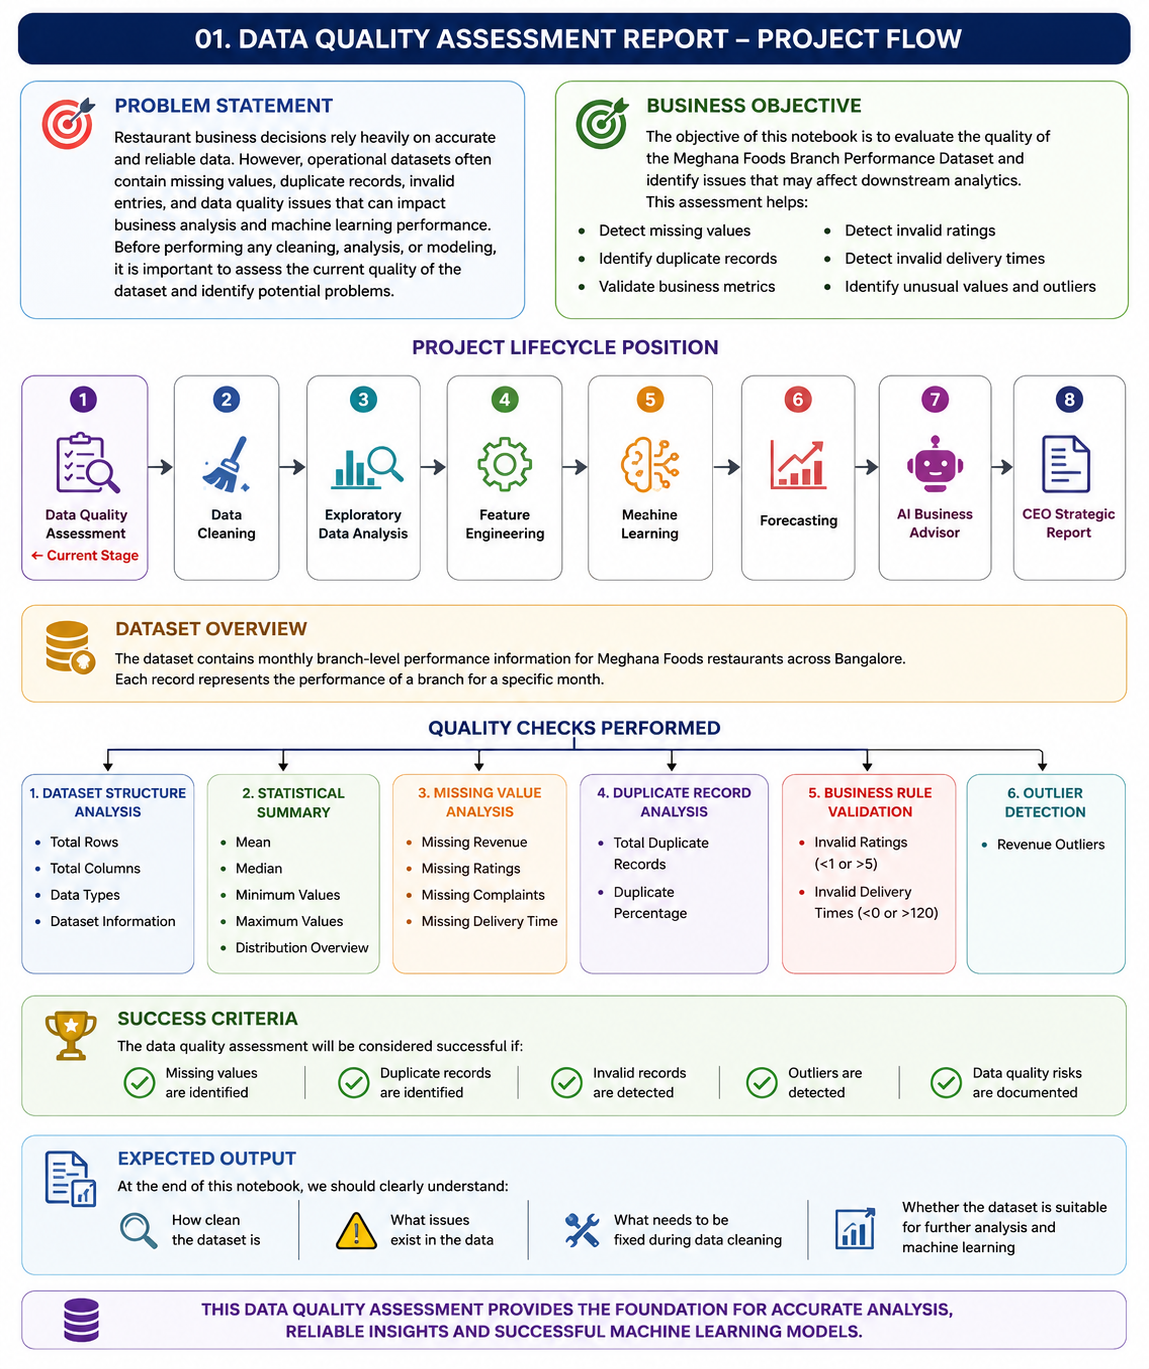

Current Stage:

Data Quality Assessment

Workflow:

1. Data Quality Assessment ← Current Stage

2. Data Cleaning

3. Exploratory Data Analysis

4. Feature Engineering

5. Machine Learning

6. Forecasting

7. AI Business Advisor

8. CEO Strategic Report

---

## Dataset Overview

The dataset contains monthly branch-level performance information for Meghana Foods restaurants across Bangalore.

Each record represents the performance of a branch for a specific month.

---

## Quality Checks Performed

The following checks are performed in this notebook:

### Dataset Structure Analysis

• Total Rows

• Total Columns

• Data Types

• Dataset Information

### Statistical Summary

• Mean

• Median

• Minimum Values

• Maximum Values

• Distribution Overview

### Missing Value Analysis

• Missing Revenue

• Missing Ratings

• Missing Complaints

• Missing Delivery Time

### Duplicate Record Analysis

• Total Duplicate Records

• Duplicate Percentage

### Business Rule Validation

• Invalid Ratings (<1 or >5)

• Invalid Delivery Times (<0 or >120)

### Outlier Detection

• Revenue Outliers

---

## Success Criteria

The data quality assessment will be considered successful if:

• Missing values are identified

• Duplicate records are identified

• Invalid records are detected

• Outliers are detected

• Data quality risks are documented

---

## Expected Output

At the end of this notebook, we should clearly understand:

• How clean the dataset is

• What issues exist in the data

• What needs to be fixed during data cleaning

• Whether the dataset is suitable for further analysis and machine learning


# Lets Start the Data Quality Report  

# Step 1: Import Libraries 

In [1]:
import pandas as pd
import numpy as np

# Step 2: Load Raw Dataset

In [2]:
df=pd.read_excel(r"D:\Skills Questions\End To End Projects\AI-Based Business Health & Revenue Forecasting Platform\Data\Meghana_food_branch_raw_data.xlsx")
df.head(5)

,Branch_ID,Branch_Name,Region,Month,Orders,Revenue,Avg_Rating,Customer_Count,Repeat_Customers,New_Customers,Complaints,Delivery_Time_Min,Performance_Level,Branch_Status,Reason
0,K_01,Koramangala,South,2024-01,14788,6122232.0,4.6,11733,8447,3286,42.0,22.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
1,K_02,Koramangala,South,2024-02,14919,5505111.0,4.7,11248,7761,3487,56.0,22.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
2,K_03,Koramangala,South,2024-03,13215,4770615.0,4.8,9529,6575,2954,67.0,21.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
3,K_04,Koramangala,South,2024-04,14904,5946696.0,4.6,11604,8238,3366,76.0,25.0,High,Healthy,"Authentic taste, flagship outlet, huge footfall"
4,K_05,Koramangala,South,2024-05,12189,4912167.0,4.5,9686,7167,2519,85.0,NaN,High,Healthy,"Authentic taste, flagship outlet, huge footfall"


# Step 3: Data Quality Report

In [3]:
def data_quality_report(df):
    print("Total Rows:", df.shape[0])
    print("-"*80)

    print("Total Columns:", df.shape[1])
    print("-"*80)

    print("Information of Data:")
    df.info()
    print("-"*80)

    print("Data Description:\n",df.describe())
    print("-"*80)
    
    print("\nMissing Values Percentage:")
    print(round((df.isnull().sum()/len(df))*100,2))
    print("-"*80)
   
    duplicate_pct = round((df.duplicated().sum()/len(df))*100,2)

    print("\nDuplicate Rows:",df.duplicated().sum())
    print("Duplicate %:",duplicate_pct,"%")
    print("-"*80)
    
    print("\nInvalid Ratings:")
    print(df[(df["Avg_Rating"] < 1) | (df["Avg_Rating"] > 5)])
    
    print("\nInvalid Delivery Time:")
    print(df[(df["Delivery_Time_Min"] < 0) | (df["Delivery_Time_Min"] > 120)])
    print("-"*80)

    Q1 = df["Revenue"].quantile(0.25)
    Q3 = df["Revenue"].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    outliers = df[(df["Revenue"] < lower) | (df["Revenue"] > upper)]
    
    print("\nRevenue Outliers:")
    print(outliers.shape[0])



In [4]:
data_quality_report(df)

Total Rows: 318
--------------------------------------------------------------------------------
Total Columns: 15
--------------------------------------------------------------------------------
Information of Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318 entries, 0 to 317
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Branch_ID          318 non-null    object 
 1   Branch_Name        318 non-null    object 
 2   Region             318 non-null    object 
 3   Month              318 non-null    object 
 4   Orders             318 non-null    int64  
 5   Revenue            316 non-null    float64
 6   Avg_Rating         316 non-null    float64
 7   Customer_Count     318 non-null    int64  
 8   Repeat_Customers   318 non-null    int64  
 9   New_Customers      318 non-null    int64  
 10  Complaints         315 non-null    float64
 11  Delivery_Time_Min  315 non-null    float64
 12  P